# Temperature evolution: (120) → (111)

Fast $\tau$ and $\beta$ versus temperature on one dual-axis figure, tracking (120) through 350 K into (111). Styled after the paper figure (Helvetica, SPT band, jammed / liquid-like guides).

Reads the saved `qdep_T*K.h5` files.

In [5]:
import sys
sys.path.append('../src/')

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap

from postprocess import discover_qdep_files, load_temperature_qdep, reflection_series

In [9]:
def apply_paper_style():
    helvetica = font_manager.FontProperties(family='Helvetica')
    font_manager.findfont(helvetica, fallback_to_default=False)
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial'],
        'font.size': 9,
        'axes.labelsize': 11,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'legend.frameon': False,
        'axes.linewidth': 1.0,
        'lines.linewidth': 1.3,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.width': 1.0,
        'ytick.major.width': 1.0,
        'xtick.major.size': 4.5,
        'ytick.major.size': 4.5,
        'xtick.top': True,
        'ytick.right': True,
        'mathtext.fontset': 'custom',
        'mathtext.rm': 'Helvetica',
        'mathtext.it': 'Helvetica:italic',
        'mathtext.bf': 'Helvetica:bold',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.03,
    })


apply_paper_style()

FIGSIZE = (4.6, 3.7)
red = '#e31a1c'
blue = '#263fc2'
SPT = (360.0, 373.0)
spt_cmap = LinearSegmentedColormap.from_list(
    'spt_warm',
    ['#fff9b0', '#ffd166', '#ff9f1c', '#e85d04'],
    N=256,
)

In [10]:
config_path = Path('../configs/config_B10.json')
config = json.loads(config_path.read_text()) if config_path.exists() else {}
base = Path(config['Base']) if config.get('Base') else Path('/Users/eriklamb/data/APS/8_ID_E/Na2B10H10')

rows = [load_temperature_qdep(p) for p in discover_qdep_files(base)]
s120 = reflection_series(rows, '120')
s111 = reflection_series(rows, '111')

T = np.concatenate([s120['temperature'], s111['temperature']])
tau = np.concatenate([s120['tau_fast'], s111['tau_fast']])
tau_e = np.concatenate([s120['tau_fast_err'], s111['tau_fast_err']])
beta = np.concatenate([s120['beta_fast'], s111['beta_fast']])
beta_e = np.concatenate([s120['beta_fast_err'], s111['beta_fast_err']])
order = np.argsort(T)
T, tau, tau_e, beta, beta_e = T[order], tau[order], tau_e[order], beta[order], beta_e[order]

print('T   ', T)
print('tau ', tau)
print('beta', beta)

T    [320. 329. 339. 350. 360. 370. 380. 399. 420.]
tau  [11.21654422 44.19134944  9.87498936  5.38681878 24.29138924 26.12082261
 38.29553801 99.79186553 74.33139785]
beta [0.66415669 0.89430708 0.93906731 1.35873784 1.17542258 0.97072346
 1.22928614 2.01380019 1.9465484 ]


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


saved ../figures/tdep_120_111.pdf


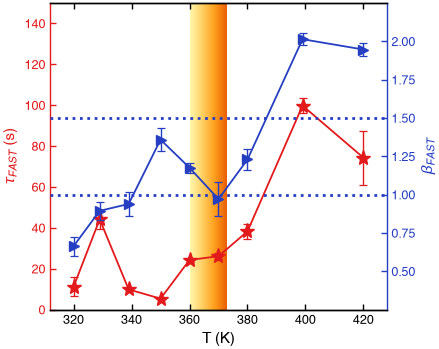

In [13]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax2 = ax.twinx()

ax.set_xlim(312, 428)
ax.set_ylim(0, 150)
ax2.set_ylim(0.25, 2.25)

ax.imshow(
    np.linspace(0, 1, 512).reshape(1, -1),
    aspect='auto',
    cmap=spt_cmap,
    extent=[SPT[0], SPT[1], *ax.get_ylim()],
    origin='lower',
    interpolation='bicubic',
    zorder=0,
)
ax.set_xlim(312, 428)

ax2.axhline(1.0, color=blue, ls=':', lw=2.0, zorder=1)
ax2.axhline(1.5, color=blue, ls=':', lw=2.0, zorder=1)

ax.errorbar(
    T, tau, yerr=tau_e, fmt='*-', color=red, ecolor=red,
    elinewidth=1.0, capsize=3, capthick=0.9, markersize=11,
    markerfacecolor=red, markeredgecolor=red, zorder=4,
)
ax2.errorbar(
    T, beta, yerr=beta_e, fmt='>-', color=blue, ecolor=blue,
    elinewidth=1.0, capsize=3, capthick=0.9, markersize=7,
    markerfacecolor=blue, markeredgecolor=blue, zorder=4,
)

ax.set_xlabel('T (K)')
ax.set_ylabel(r'$\tau_{FAST}$ (s)', color=red)
ax2.set_ylabel(r'$\beta_{FAST}$', color=blue)
ax.set_xticks([320, 340, 360, 380, 400, 420])
ax.set_yticks(np.arange(0, 151, 20))
ax2.set_yticks(np.arange(0.50, 2.01, 0.25))

ax.tick_params(axis='y', colors=red)
ax2.tick_params(axis='y', colors=blue)
ax.spines['left'].set_color(red)
ax2.spines['right'].set_color(blue)
ax.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax.spines['top'].set_color('k')
ax2.spines['top'].set_color('k')
ax.spines['bottom'].set_color('k')
ax2.spines['bottom'].set_color('k')

out = Path('../figures')
out.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(out / 'tdep_120_111.pdf')
fig.savefig(out / 'tdep_120_111.png')
print('saved', out / 'tdep_120_111.pdf')